<a href="https://colab.research.google.com/github/RubenAndreeB/TelecomX_AluraLatam/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Extracción(E - Extract)

✅ Cargar los datos directamente desde la API utilizando Python.

✅ Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Nos encontramos con tres columnas que cuentan con diccionarios que hacen referencia a su columna, por lo que necesitamos solucionar ese inconveniente.

In [2]:
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

for columna in columnas_anidadas:
    df_anidado = pd.json_normalize(df[columna])
    df = pd.concat([df, df_anidado], axis=1)
    df = df.drop(columna, axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 🔧 Transformación (T - Transform)

## Conoce el conjunto de datos
✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión.

In [3]:
# Exploramos las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Este es el diccionario de datos:
- customerID: número de identificación único de cada cliente
- Churn: si el cliente dejó o no la empresa
- gender: género (masculino y femenino)
- SeniorCitizen: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- Partner: si el cliente tiene o no una pareja
- Dependents: si el cliente tiene o no dependientes
- tenure: meses de contrato del cliente
- PhoneService: suscripción al servicio telefónico
- MultipleLines: suscripción a más de una línea telefónica
- InternetService: suscripción a un proveedor de internet
- OnlineSecurity: suscripción adicional de seguridad en línea
- OnlineBackup: suscripción adicional de respaldo en línea
- DeviceProtection: suscripción adicional de protección del dispositivo
- TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
- StreamingTV: suscripción de televisión por cable
- StreamingMovies: suscripción de streaming de películas
- Contract: tipo de contrato
- PaperlessBilling: si el cliente prefiere recibir la factura en línea
- PaymentMethod: forma de pago
- Charges.Monthly: total de todos los servicios del cliente por mes
- Charges.Total: total gastado por el cliente

Viendo eso, el unico que esta mal, es el ultimo Charges.Total, ya que son valores numericos de gastos.

No nos funciona, porque tenemos strings con ' ' por lo que primero debemos limpiar esos espacios vacios.

In [4]:
import numpy as np

df['Charges.Total'] = df['Charges.Total'].str.replace (' ', '0')
df['Charges.Total'] = df['Charges.Total'].astype(np.float64)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## Comprobación de incoherencias en los datos

In [6]:
print(f'Existen {len(df.customerID.unique())} customerID diferentes.')

for col in df.columns:
  print(f'La columna {col} cuenta con las siguientes opciones: {df[col].unique()}')

Existen 7267 customerID diferentes.
La columna customerID cuenta con las siguientes opciones: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
La columna Churn cuenta con las siguientes opciones: ['No' 'Yes' '']
La columna gender cuenta con las siguientes opciones: ['Female' 'Male']
La columna SeniorCitizen cuenta con las siguientes opciones: [0 1]
La columna Partner cuenta con las siguientes opciones: ['Yes' 'No']
La columna Dependents cuenta con las siguientes opciones: ['Yes' 'No']
La columna tenure cuenta con las siguientes opciones: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
La columna PhoneService cuenta con las siguientes opciones: ['Yes' 'No']
La columna MultipleLines cuenta con las siguientes opciones: ['No' 'Yes' 'No phone service']
La columna InternetService cue

Podemos observar que nos encontramos con las colmnas con diferentes opciones, por ejemplo Churn, tiene como opcion '' cuando eso no significa nada, por lo que debemos corregir.

In [7]:
df['Churn'] = df['Churn'].replace('', 'No')
df['MultipleLines'] = df['MultipleLines'].str.replace('No phone service', 'No')

columnas = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for columna in columnas:
  df[columna] = df[columna].replace('No internet service', 'No')

for col in df.columns:
  print(f'La columna {col} cuenta con las siguientes opciones: {df[col].unique()}')

La columna customerID cuenta con las siguientes opciones: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
La columna Churn cuenta con las siguientes opciones: ['No' 'Yes']
La columna gender cuenta con las siguientes opciones: ['Female' 'Male']
La columna SeniorCitizen cuenta con las siguientes opciones: [0 1]
La columna Partner cuenta con las siguientes opciones: ['Yes' 'No']
La columna Dependents cuenta con las siguientes opciones: ['Yes' 'No']
La columna tenure cuenta con las siguientes opciones: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
La columna PhoneService cuenta con las siguientes opciones: ['Yes' 'No']
La columna MultipleLines cuenta con las siguientes opciones: ['No' 'Yes']
La columna InternetService cuenta con las siguientes opciones: ['DSL' 'Fiber optic' 'No'

## Columna de cuentas diarias (Opcional)
Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

In [8]:
df['Charges.Daily'] = df['Charges.Monthly'] / 30
df['Charges.Daily']

,Charges.Daily
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7262,1.838333
7263,2.836667
7264,1.676667
7265,2.261667



## Estandarización y transformación de datos (opcional)

La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [9]:
columns_with_yes_no = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
for column in columns_with_yes_no:
  df[column] = df[column].str.replace('No', '0')
  df[column] = df[column].str.replace('Yes', '1')
  df[column] = df[column].astype(int)

# 📊 Carga y análisis(L - Load & Analysis)

## Análisis Descriptivo
Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

📌 Consejos:

🔗 [Documentación](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) de DataFrame.describe()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   int64  
 11  OnlineBackup      7267 non-null   int64  
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Contract          7267 non-null   object 


In [11]:
df.describe()


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Charges.Daily
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157337
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Distribución de evasión
En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

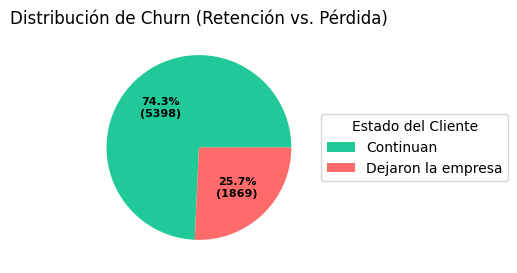

In [12]:
import matplotlib.pyplot as plt

conteos_churn = df['Churn'].value_counts()
data = conteos_churn.values
etiquetas = ['Continuan', 'Dejaron la empresa']
colores = ['#20c997', '#ff6b6b']

fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))

def setformat_porcent_count(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return "{:.1f}%\n({:d})".format(pct, absolute)

wedges, texts, autotexts = ax.pie(
    data,
    autopct=lambda pct: setformat_porcent_count(pct, data),
    textprops=dict(color="black"),
    colors=colores
)

ax.legend(
    wedges,
    etiquetas,
    title="Estado del Cliente",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.setp(autotexts, size=8, weight="bold")
ax.set_title("Distribución de Churn (Retención vs. Pérdida)", loc='center')

plt.show()

## Recuento de evasión por variables categóricas
Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

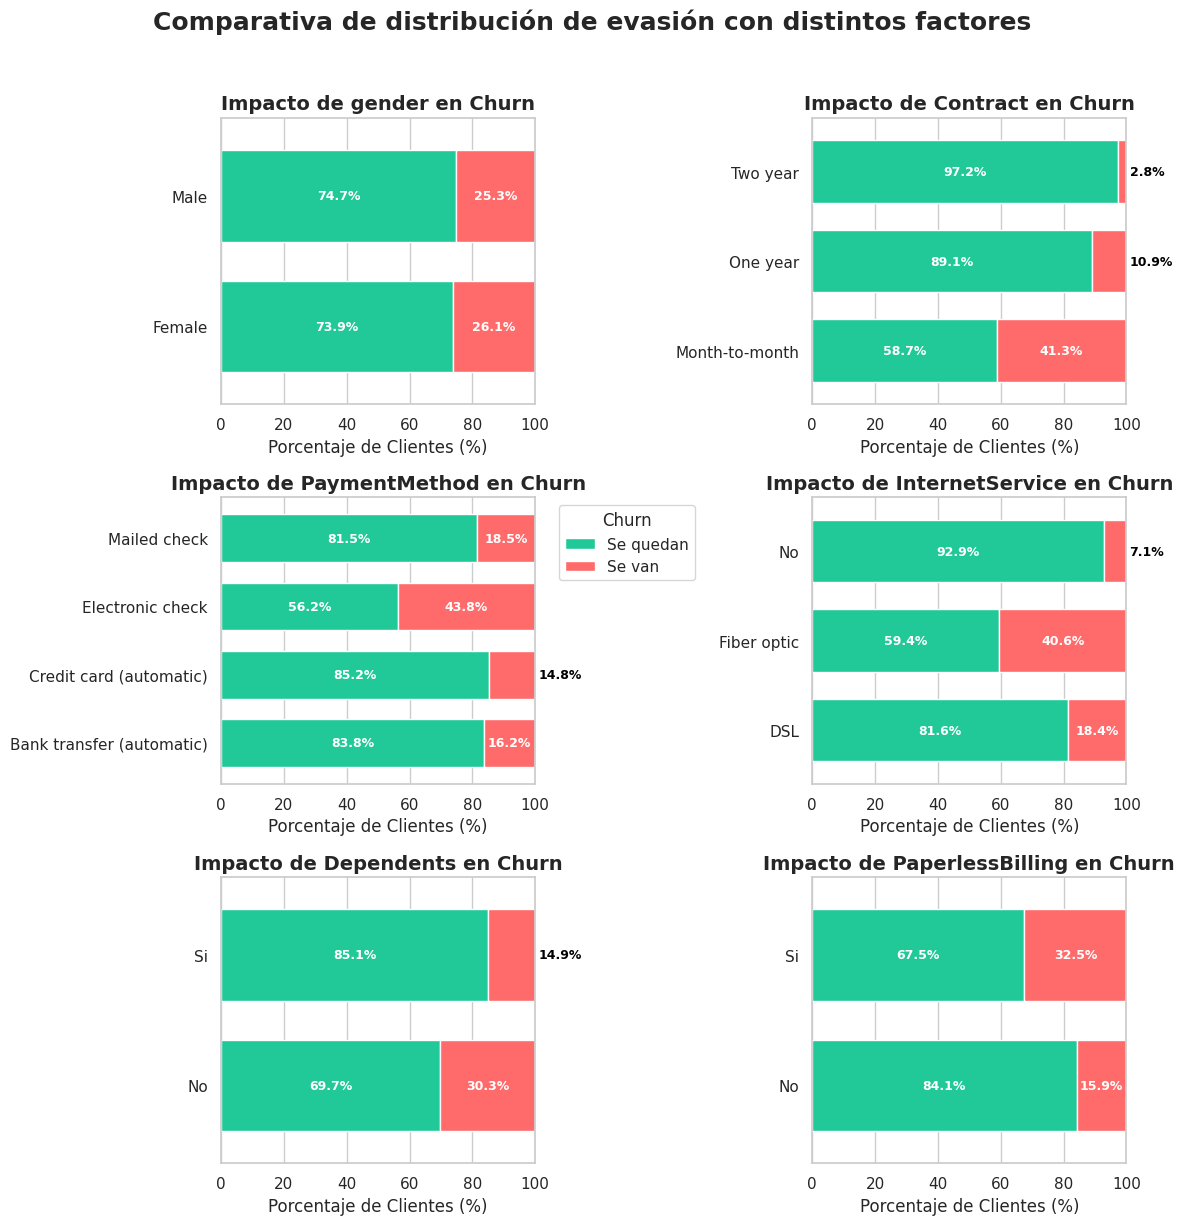

In [13]:
import seaborn as sns

sns.set_theme(style="whitegrid")
columnas_explorar = ['gender', 'Contract', 'PaymentMethod', 'InternetService', 'Dependents', 'PaperlessBilling']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
axes = axes.flatten()

colores_modernos = ['#20c997', '#ff6b6b']

for i, columna in enumerate(columnas_explorar):
    tabla_porcentajes = pd.crosstab(df[columna].replace({0: 'No', 1: 'Si', '0': 'No', '1': 'Si'}),
                                    df['Churn'],
                                    normalize='index') * 100

    tabla_porcentajes.plot(
        kind='barh',
        stacked=True,
        ax=axes[i],
        color=colores_modernos,
        edgecolor='white',
        width=0.7
    )

    axes[i].set_title(f'Impacto de {columna} en Churn', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Porcentaje de Clientes (%)')

    for container in axes[i].containers:
        for bar in container:
            width = bar.get_width()

            if width < 15:
                axes[i].text(
                    bar.get_x() + width + 1,
                    bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='left',
                    va='center',
                    color='black',
                    fontweight='bold',
                    fontsize=9
                )
            else:
                axes[i].text(
                    bar.get_x() + width/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='center',
                    va='center',
                    color='white',
                    fontweight='bold',
                    fontsize=9
                )

    axes[i].set_xlim(0, 100)

    if i == 2:
        axes[i].legend(title='Churn', labels=['Se quedan', 'Se van'], bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

fig.suptitle('Comparativa de distribución de evasión con distintos factores', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Conteo de evasión por variables numéricas

En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

Nota: Iba a agregar el gasto diario, pero al ser una copia de la estadistica de gasto mensual, pero dividida en los dias del mes, pues esta exactamente igual

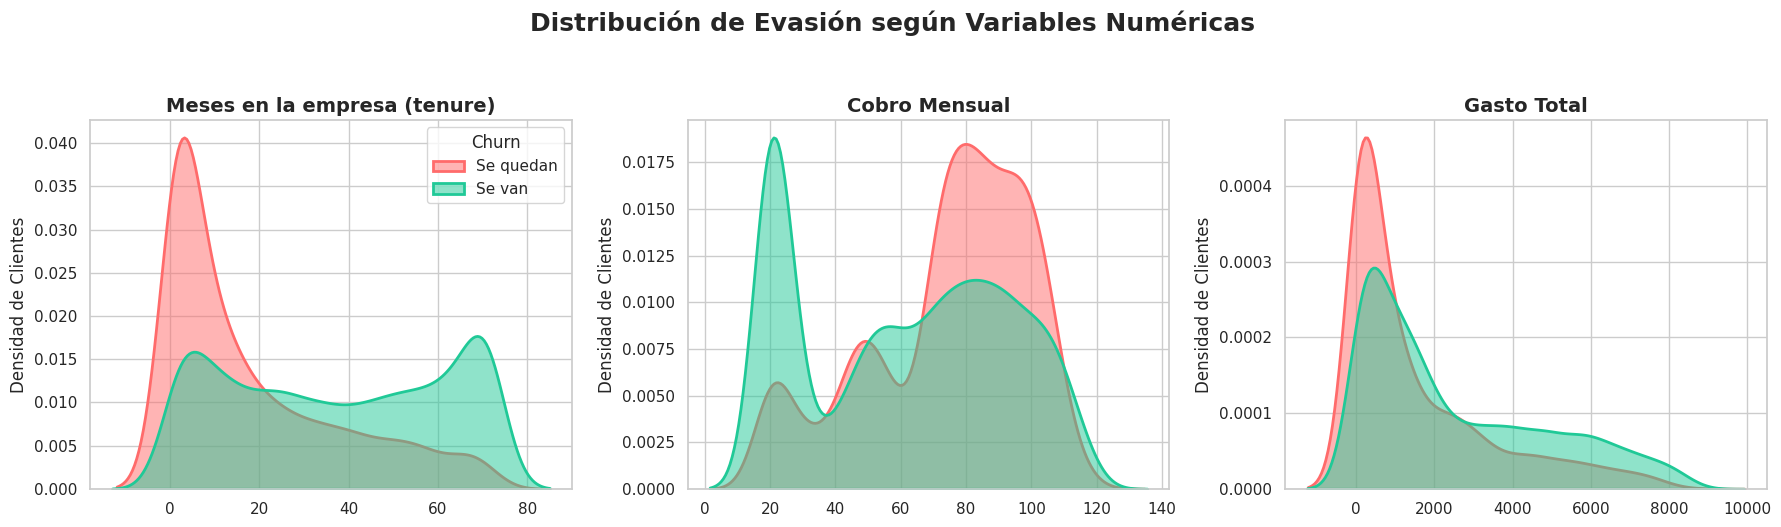

In [23]:
sns.set_theme(style="whitegrid")

columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total']
titulos_graficas = ['Meses en la empresa (tenure)', 'Cobro Mensual', 'Gasto Total']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
axes = axes.flatten()

colores = ['#20c997', '#ff6b6b']

for i, columna in enumerate(columnas_numericas):

    sns.kdeplot(
        data=df,
        x=columna,
        hue=df['Churn'],
        ax=axes[i],
        fill=True,
        palette=colores,
        alpha=0.5,
        linewidth=2,
        common_norm=False
    )

    axes[i].set_title(titulos_graficas[i], fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Densidad de Clientes')
    axes[i].set_xlabel('')


    if i != 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Churn', labels=['Se quedan', 'Se van'])

fig.suptitle('Distribución de Evasión según Variables Numéricas', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Informe Final: Análisis de Evasión de Clientes (Churn) en TelecomX

## 🔹 Introducción
En el modelo de negocio de las telecomunicaciones, la retención de clientes es un pilar para la rentabilidad. El costo de adquirir un nuevo usuario suele ser mucho mayor que el de retener a uno existente.
El presente análisis tiene como objetivo principal estudiar el fenómeno de la **evasión de clientes (Churn)** dentro de nuestra base de datos. A través del análisis exploratorio, buscamos identificar patrones demográficos, de comportamiento y financieros que caracterizan a los usuarios que abandonan el servicio, con el fin de proponer estrategias basadas en datos para mitigar esta pérdida.

## 🔹 Limpieza y Tratamiento de Datos
Para garantizar la calidad del análisis, el conjunto de datos original (proveniente de un archivo JSON multinivel) fue sometido a un riguroso proceso de limpieza y estructuración:
1. **Importación y Desanidación:** Se extrajeron los datos en formato JSON y se aplanaron las columnas anidadas (`customer`, `phone`, `internet`, `account`) convirtiendo sus diccionarios internos en columnas individuales operables utilizando herramientas de Pandas.
2. **Tratamiento de valores sin llenar:** Dentro de la base de datos existian valores que no permitian el manejo de los mismos, por lo que se uso `replace()` para estabdarizar y posteriormente trabajar con ellos.
3. **Transformación de Tipos de Datos:** Se estandarizaron las variables para asegurar que los valores numéricos (`Charges`, `tenure`, etc) y categóricos estuvieran en el formato correcto para su evaluación matemática y visual.
4. **Mapeo de Categorías:** Para mejorar la legibilidad de las visualizaciones y el reporte, los valores con respuesta en cadena de caracteres (`string`) originales de distintas columnas, fueron transformados a valores binarios para la facilidad de trabajo (1 para "Yes" y 0 para "No").

## 🔹 Análisis Exploratorio de Datos (EDA)
El análisis visual nos permitió aislar las variables de mayor impacto en la decisión de abandono de los clientes. Los enfoques principales fueron:

* **Tasa de Retención General (Grafica de Pastel):** A través de un gráfico de proporción, determinamos que la tasa de Churn actual es del **25.7%**, mientras que el **74.3%** de los clientes permanecen activos.
* **Impacto Categórico (Gráficos de Barras Apiladas):** Se cruzaron variables clave como el género, tipo de contrato y método de pago. Descubrimos visualmente que características como el *Género* no tienen una influencia representativa, mientras que el *Tipo de Contrato* altera drásticamente la distribución.
* **Comportamiento Financiero y Temporal (Gráficos de Densidad KDE):** Se evaluaron las variables numéricas (Tiempo en la empresa, Gasto Mensual y Gasto Total), permitiendo observar exactamente en qué momento del ciclo de vida del cliente ocurre la mayor cantidad de cancelaciones.

## 🔹 Conclusiones e Insights Principales
A partir de los datos analizados, extrajimos los siguientes hallazgos críticos:

1. **El riesgo inicial es el más alto:** La gráfica de densidad de `tenure` demuestra que el mayor volumen de cancelaciones ocurre durante los primeros **1 a 4** meses de servicio. Los clientes que superan la barrera del primer año tienden a ser mucho más leales.
2. **El contrato "Mes a Mes" es el principal punto de fuga:** Los clientes sin un plazo forzoso anual o bianual representan la inmensa mayoría de la tasa de Churn.
3. **Sensibilidad al precio mensual:** Los usuarios que pagan tarifas mensuales más altas (concentrados en el pico de los **$70 - 100**) muestran una propensión notablemente mayor a abandonar la empresa en comparación con los que tienen planes básicos.
4. **Métodos de pago como fricción:** Se observó que los clientes que utilizan **Electronic check** como método de pago o que prefieren la facturación electrónica (`PaperlessBilling`) tienen una ligera tendencia mayor a la evasión.
5. **Satisfaccion con internet de fibra optica:** Se observo que hay un gran incremento de evsaion cuando el cliente tiene como servicio de internet de fibra optica a diferencia de DSL o cuando no tiene . Una diferencia de mas de **20%** respecto a DSL y mas de **30%** en consideracion con los que no tienen internet.

## 🔹 Recomendaciones Estratégicas
Basándonos en la evidencia de los datos, sugerimos las siguientes acciones accionables para reducir el Churn:

* **Rediseñar el "Onboarding" (Primeros 90 días):** Al ser los primeros meses el punto más crítico, es imperativo implementar un programa de seguimiento al cliente recién adquirido. Ofrecer soporte proactivo, tutoriales de uso o una llamada de calidad en el mes 1 puede evitar la fuga temprana.
* **Incentivar la migración a contratos anuales:** Puesto que los contratos mensuales son volátiles, el equipo de marketing debe crear campañas agresivas (descuentos en el cobro mensual, meses gratis o upgrades de velocidad) para convencer a los usuarios mensuales de firmar contratos de 1 o 2 años.
* **Revisión de percepción de valor en planes Premium:** Dado que los clientes con pagos altos se van más, la empresa debe auditar sus planes más costosos. ¿Están recibiendo un servicio equivalente a lo que pagan? Se recomienda agregar beneficios exclusivos de retención (ej. soporte técnico prioritario gratuito) para estos segmentos altos. Mas enfocado en los clientes que contraten internet, en especial la fibra optica al ser un producto premium.